In [25]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json

# 设置全局字体为 Times New Roman
%config InlineBackend.figure_format = 'retina'
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams.update({"font.size": 16})

# 启用 LaTeX 渲染
plt.rcParams["text.usetex"] = True

N = 20
r = 1
seed = 43
exact = -3.488279085971956

# r_list = np.array([1, 2, 4]) # Trotter steps
# r_list = np.array([1, 2, 6]) # Trotter steps
r_list = np.array([1, 2, 3, 7]) # Trotter steps

x = np.flip(r_list**2) # noise levels
# x = np.flip(r_list**3)  # noise levels
print('noise_levels:', x)
# r_list *= 2

def get_y_values(noise_level, r_list, N, seed):
    y_values = []
    for i in range(len(r_list)):
        p = Path(f'sample_results_N_{N}/r_{r_list[i]}_noise_{int(noise_level[i])}_seed_{seed}.txt')
        if not p.exists():
            raise FileNotFoundError(f'Expected result file not found: {p}')
        # 读取文本，尝试解析 'key = value' 或直接的数值文本
        txt = p.read_text(encoding='utf-8').strip()
        if '=' in txt:
            val_str = txt.split('=')[-1].strip()
        else:
            val_str = txt
        try:
            y_values.append(float(val_str))
        except ValueError as e:
            raise ValueError(f'Cannot parse numeric value from {p}: {val_str}') from e
    return y_values

y = get_y_values(x, r_list, N, seed) # 1D extrapolation
y0 = get_y_values(0 * np.ones(len(x)), r_list, N, seed) # zero noise
y1 = get_y_values(x[-1] * np.ones(len(x)), r_list, N, seed) # 1 noise
y2 = get_y_values(x[-2] * np.ones(len(x)), r_list, N, seed) # 8 noise
y3 = get_y_values(x[-3] * np.ones(len(x)), r_list, N, seed) # 64 noise
if len(r_list) > 3:
    y4 = get_y_values(x[-4] * np.ones(len(x)), r_list, N, seed) #

noise_levels: [49  9  4  1]


In [26]:
# coefficients for extrapolation
b_list = np.ones(len(r_list))
if r_list[-1]== 2: # [1,2]
    b_list = np.array([1/3, -4/3])
elif r_list[-1]== 4 or r_list[-1]== 8: # [1,2,4]
    b_list = np.array([1/45, -4/9, 64/45])
elif r_list[-1]== 6: # [1,2,6]
    b_list = np.array([1/105, -1/6, 81/70])
elif r_list[-1]== 7: # [1,2,3,7]
    b_list = np.array([-1/1152, 64/675, -729/1600, 117649/86400])


def get_richardson_coeffs(x_array, p=1):
    """
    x_array: 步长或参数数组，例如 [64, 8, 1]
    p: 误差主项的幂次（通常线性误差 p=1，对称误差 p=2）
    """
    n = len(x_array)
    # 构造范德蒙矩阵类型的方程组
    # 第一行：alpha1 + alpha2 + alpha3 = 1
    # 第二行：alpha1 * x1^p + alpha2 * x2^p + alpha3 * x3^p = 0
    # 第三行：alpha1 * x1^(2p) + alpha2 * x2^(2p) + alpha3 * x3^(2p) = 0
    
    A = np.zeros((n, n))
    for i in range(n):
        A[i, :] = x_array ** (i * p)
    
    # 目标向量：[1, 0, 0, ...]
    b = np.zeros(n)
    b[0] = 1
    
    coeffs = np.linalg.solve(A, b)
    return coeffs

# x = np.array([64, 8, 1]) # noise_list
coeffs = get_richardson_coeffs(x, p=1)

print(f"对于 noise = {x}, ZNE 组合系数为:")
for i, c in enumerate(coeffs):
    print(f"noise = {x[i]}: {c:.10f}")

# test reverse the order of 2D extrapolation (vectorized)
# 可以看成列向量，从上往下是 r = 1 2 4 处的值，先对不同噪声水平作 ZNE，注意 y3 才是 64 倍噪声
per_r = coeffs[-1] * np.asarray(y1) + coeffs[-2] * np.asarray(y2) + coeffs[-3] * np.asarray(y3) 
if len(r_list) > 3:
    per_r += coeffs[-4] * np.asarray(y4)
    
res = np.dot(b_list, per_r)
print(f'2D extrapolation value: {res}')

对于 noise = [49  9  4  1], ZNE 组合系数为:
noise = 49: -0.0004166667
noise = 9: 0.1225000000
noise = 4: -0.6533333333
noise = 1: 1.5312500000
2D extrapolation value: -3.034725407178637


In [27]:
print(f"r_list: {r_list}")

print(f'noise_ratio: {x}')

# print(f'noise_ratio: {0}')
    
extraplated_1D = sum(b * y_i for b, y_i in zip(b_list, y))

print(f'Exact value: {exact}')

# print('Joint Error Mitigation Results:')
# print(f'Observable value for different joint r: {y}')
print(f'1D extrapolated value: {extraplated_1D}')

extraplated_y0 = sum(b * y_i for b, y_i in zip(b_list, y0))
extraplated_y1 = sum(b * y_i for b, y_i in zip(b_list, y1))
extraplated_y2 = sum(b * y_i for b, y_i in zip(b_list, y2))
extraplated_y3 = sum(b * y_i for b, y_i in zip(b_list, y3))
    
extrapolated_2D = extraplated_y1 * coeffs[-1] + extraplated_y2 * coeffs[-2] + extraplated_y3 * coeffs[-3]

if len(r_list) > 3:
    extraplated_y4 = sum(b * y_i for b, y_i in zip(b_list, y4))
    extrapolated_2D += extraplated_y4 * coeffs[-4]

print(f'2D extrapolation value: {extrapolated_2D}')
print(f'Nosie-free extrapolation value: {extraplated_y0}')

r_list: [1 2 3 7]
noise_ratio: [49  9  4  1]
Exact value: -3.488279085971956
1D extrapolated value: -3.247873009259056
2D extrapolation value: -3.0347254071786374
Nosie-free extrapolation value: -3.4285944050923733


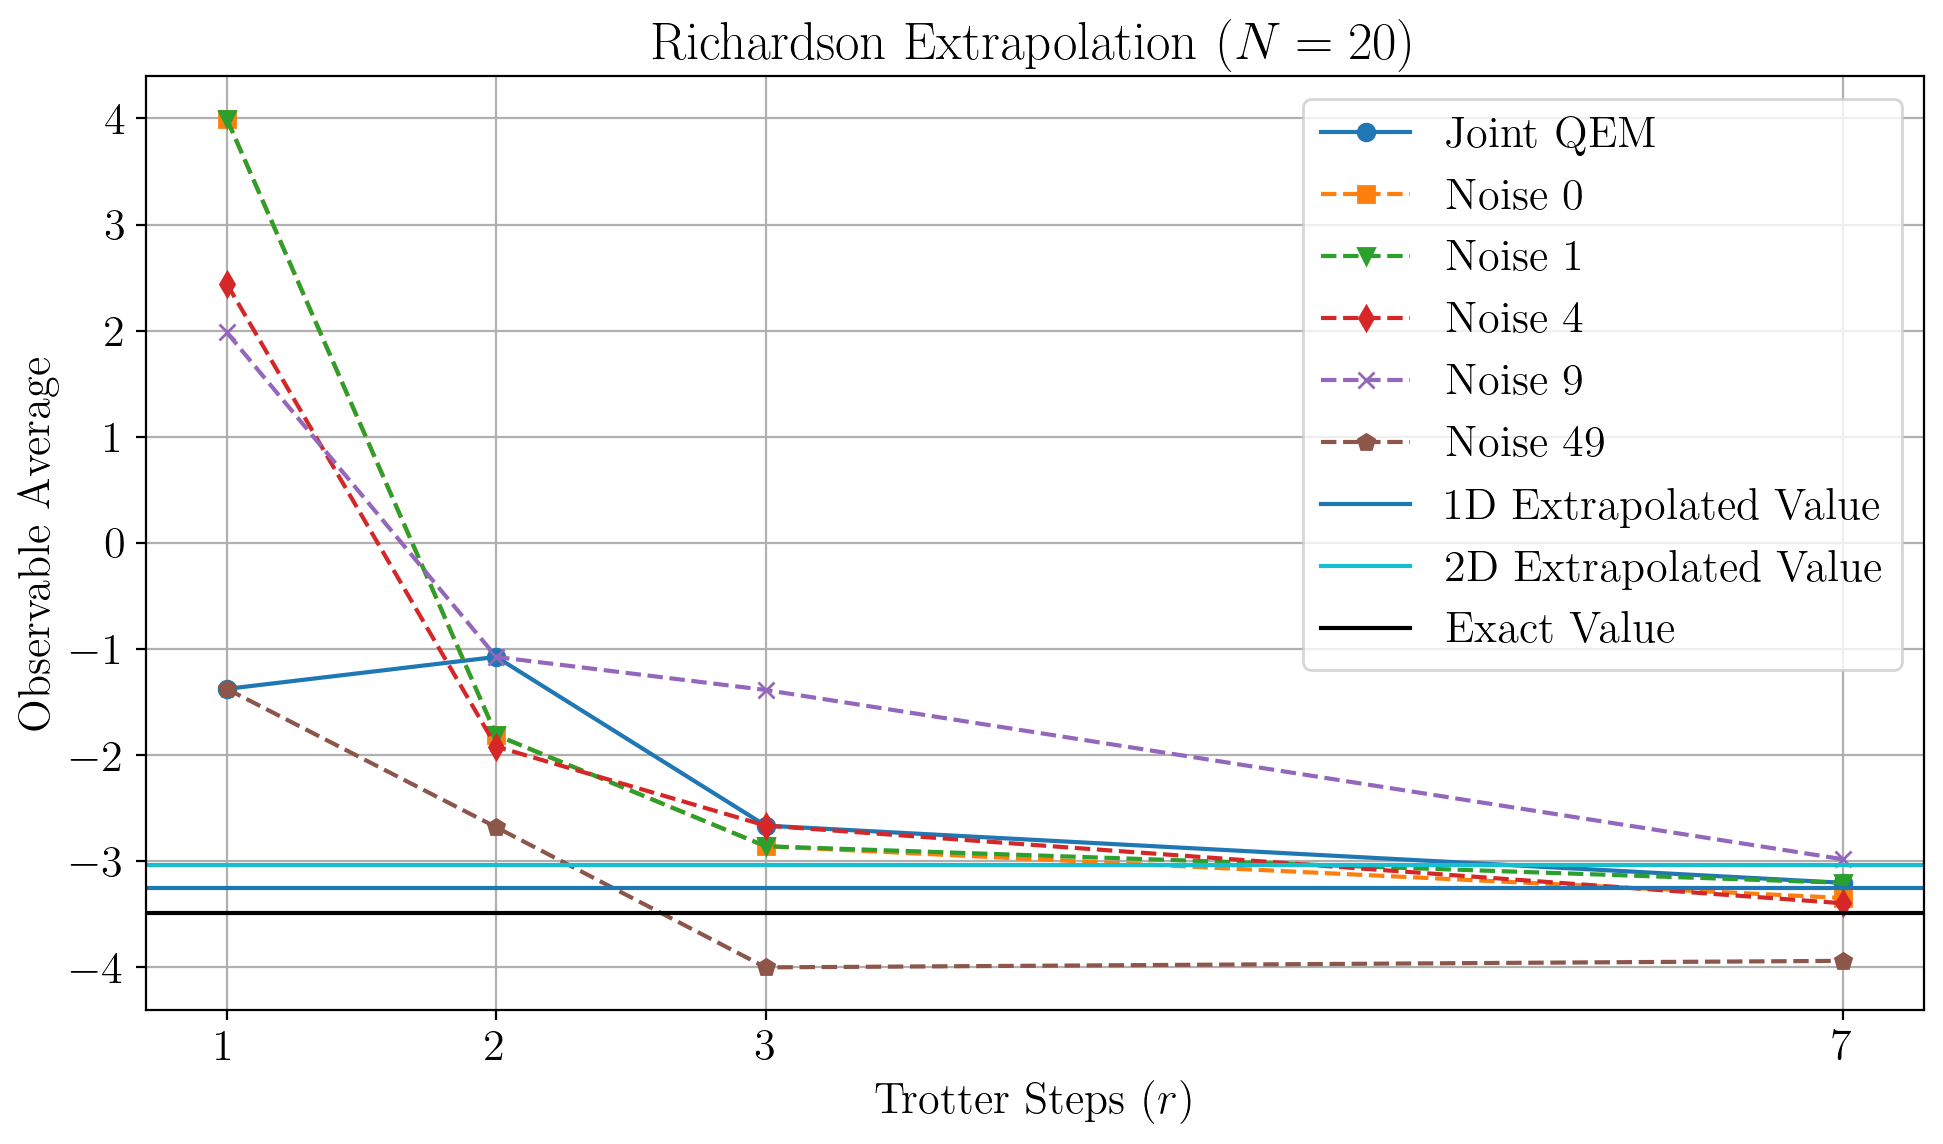

In [28]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 6))

ax.plot(r_list, y, 'o-', label='Joint QEM')
ax.plot(r_list, y0, 's--', label='Noise 0')
ax.plot(r_list, y1, 'v--', label=f'Noise {x[-1]}')
ax.plot(r_list, y2, 'd--', label=f'Noise {x[-2]}')
ax.plot(r_list, y3, 'x--', label=f'Noise {x[-3]}')
if len(r_list) > 3:
    ax.plot(r_list, y4, 'p--', label=f'Noise {x[-4]}')

ax.axhline(extraplated_1D, color='C0', linestyle='-', label='1D Extrapolated Value')
if 0:
    ax.axhline(extraplated_y0, color='C1', linestyle='--')
    ax.axhline(extraplated_y1, color='C2', linestyle='--')
    ax.axhline(extraplated_y2, color='C3', linestyle='--')
    ax.axhline(extraplated_y3, color='C4', linestyle='--')

ax.axhline(y=extrapolated_2D, color='C9', linestyle='-', label='2D Extrapolated Value')
ax.axhline(y=exact, color='k', linestyle='-', label='Exact Value')

ax.set(xlabel='Trotter Steps ($r$)', 
       ylabel='Observable Average', 
       title=f'Richardson Extrapolation ($N={N}$)',
       xticks=r_list)

ax.legend(loc='best')
ax.grid()
fig.tight_layout()
plt.show()

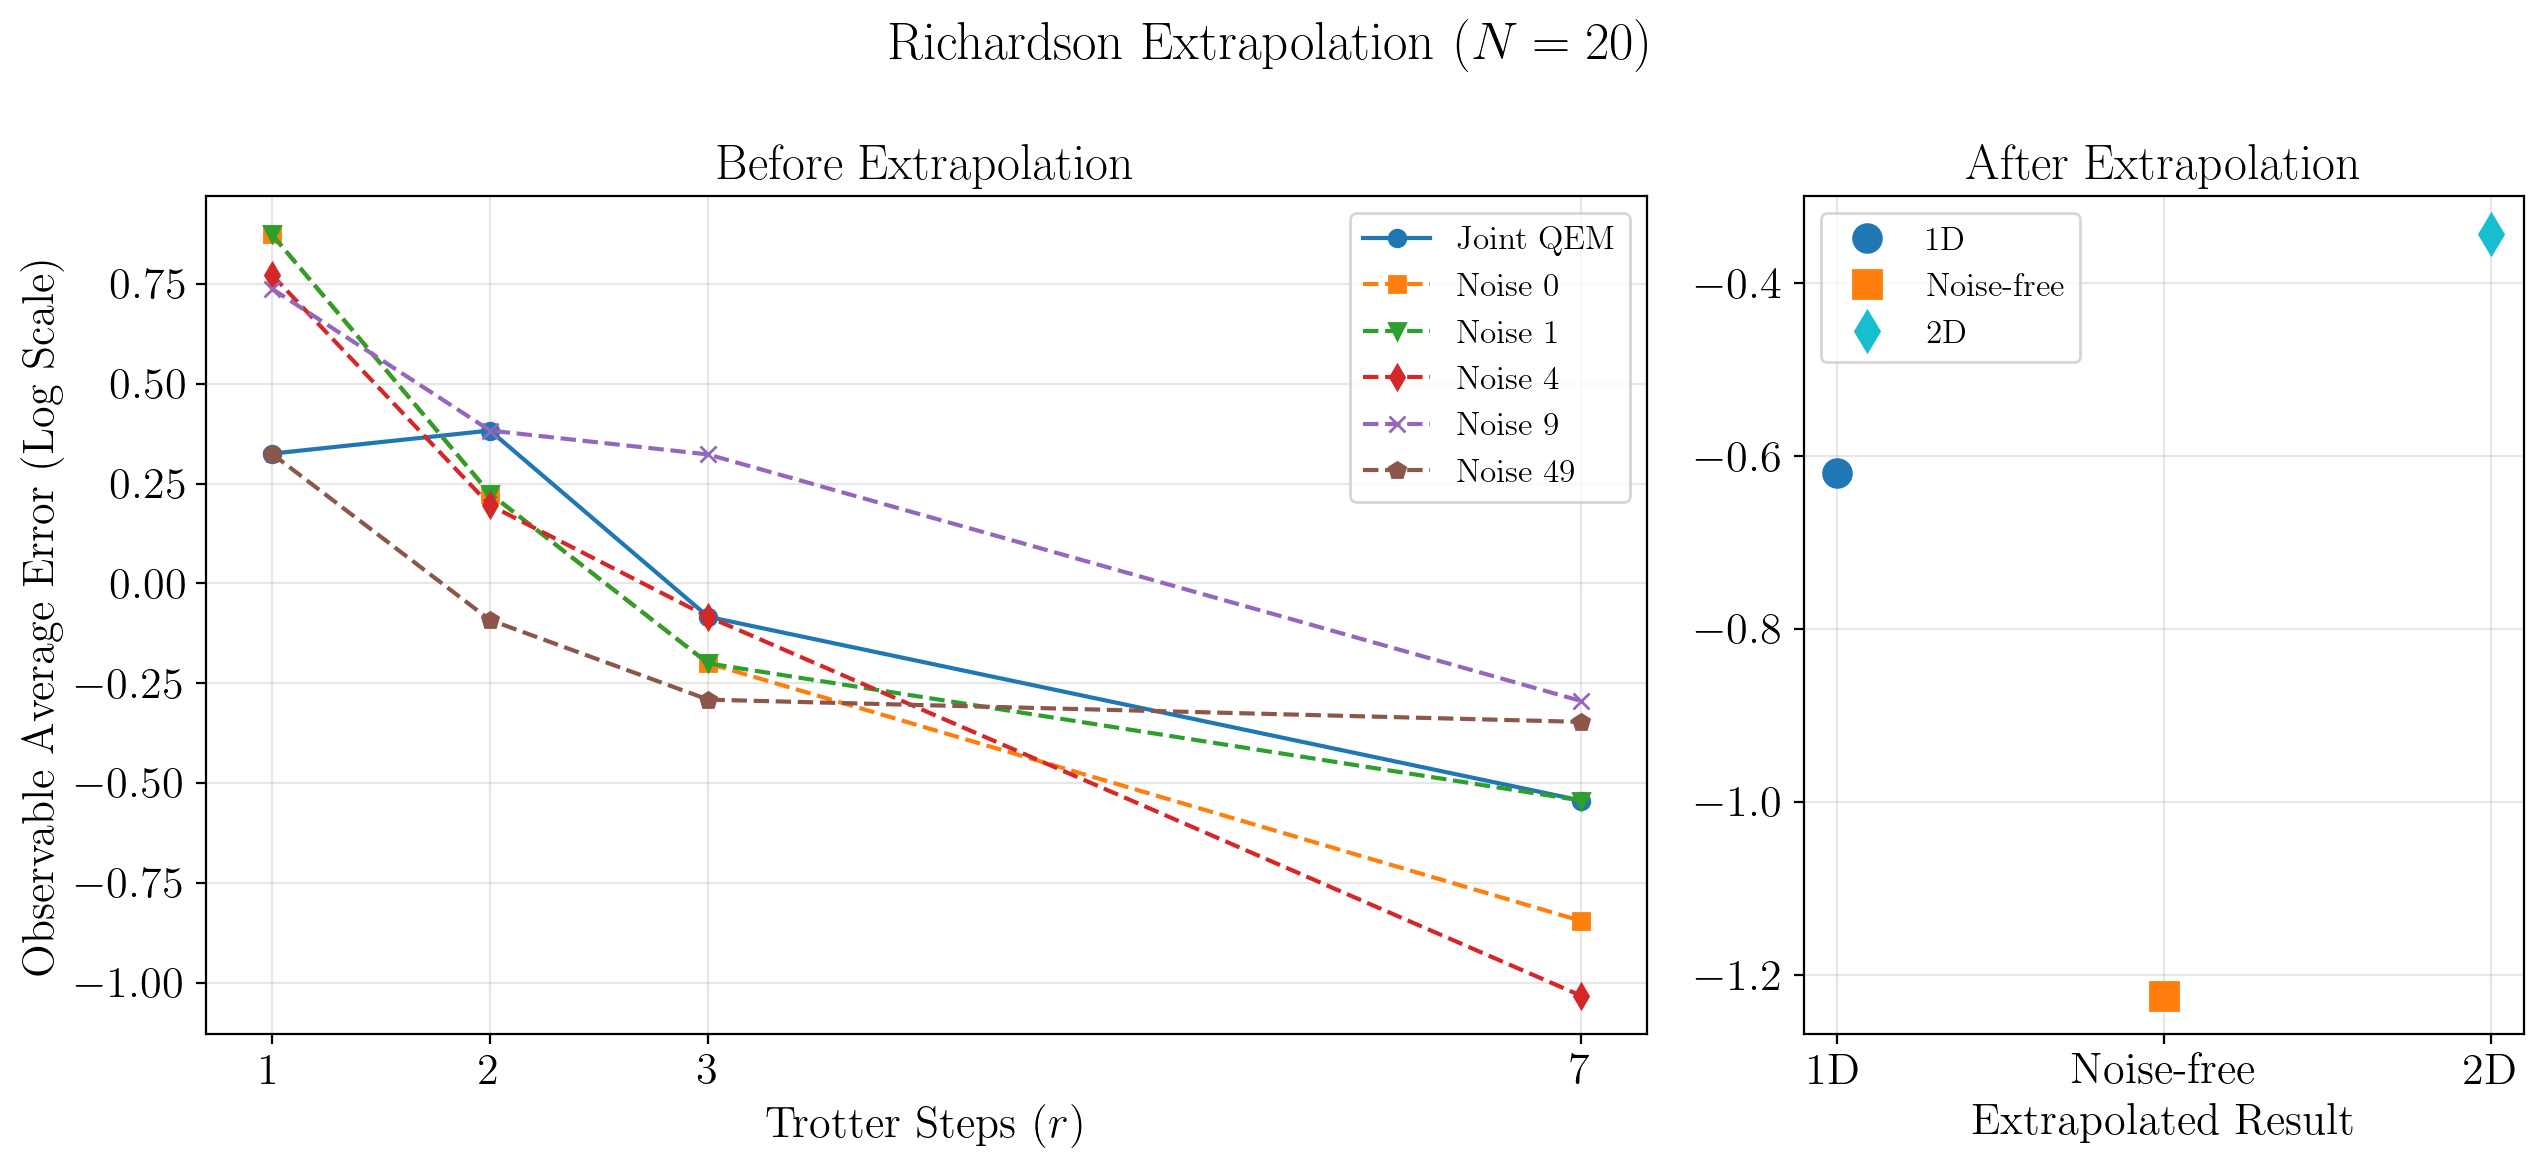

In [29]:
raw_error_series = [
    ("Joint QEM", r_list, np.log10(np.abs(np.array(y) - exact)), "o-", "C0"),
    ("Noise 0", r_list, np.log10(np.abs(np.array(y0) - exact)), "s--", "C1"),
    (f"Noise {x[-1]}", r_list, np.log10(np.abs(np.array(y1) - exact)), "v--", "C2"),
    (f"Noise {x[-2]}", r_list, np.log10(np.abs(np.array(y2) - exact)), "d--", "C3"),
    (f"Noise {x[-3]}", r_list, np.log10(np.abs(np.array(y3) - exact)), "x--", "C4"),
]
if len(r_list) > 3:
    raw_error_series.append((f"Noise {x[-4]}", r_list, np.log10(np.abs(np.array(y4) - exact)), "p--", "C5"))

after_error_labels = ["1D", "Noise-free", "2D"]
after_error_values = np.array([
    np.log10(abs(extraplated_1D - exact)),
    np.log10(abs(extraplated_y0 - exact)),
    np.log10(abs(extrapolated_2D - exact)),
])
after_error_markers = ["o", "s", "d"]
after_error_colors = ["C0", "C1", "C9"]

fig, axs = plt.subplots(
    1,
    2,
    figsize=(13, 6),
    # sharey=True,
    gridspec_kw={"width_ratios": [2, 1]},
)

for label, x_values, y_values, style, color in raw_error_series:
    axs[0].plot(x_values, y_values, style, color=color, label=label)
axs[0].set_title("Before Extrapolation", fontsize=18)
axs[0].set_xlabel("Trotter Steps ($r$)")
axs[0].set_ylabel("Observable Average Error (Log Scale)")
axs[0].set_xticks(r_list)
axs[0].legend(loc="best", fontsize=12)
axs[0].grid(alpha=0.3)

x_after = np.arange(1, len(after_error_labels) + 1)
for xpos, ypos, label, marker, color in zip(x_after, after_error_values, after_error_labels, after_error_markers, after_error_colors):
    axs[1].plot(xpos, ypos, marker=marker, color=color, markersize=10, linestyle="None", label=label)
axs[1].set_title("After Extrapolation", fontsize=18)
axs[1].set_xlabel("Extrapolated Result")
axs[1].set_xticks(x_after)
axs[1].set_xticklabels(after_error_labels)
axs[1].grid(alpha=0.3)
axs[1].legend(loc="best", fontsize=12)

fig.suptitle(f"Richardson Extrapolation ($N={N}$)", y=0.98)
fig.tight_layout()
plt.show()

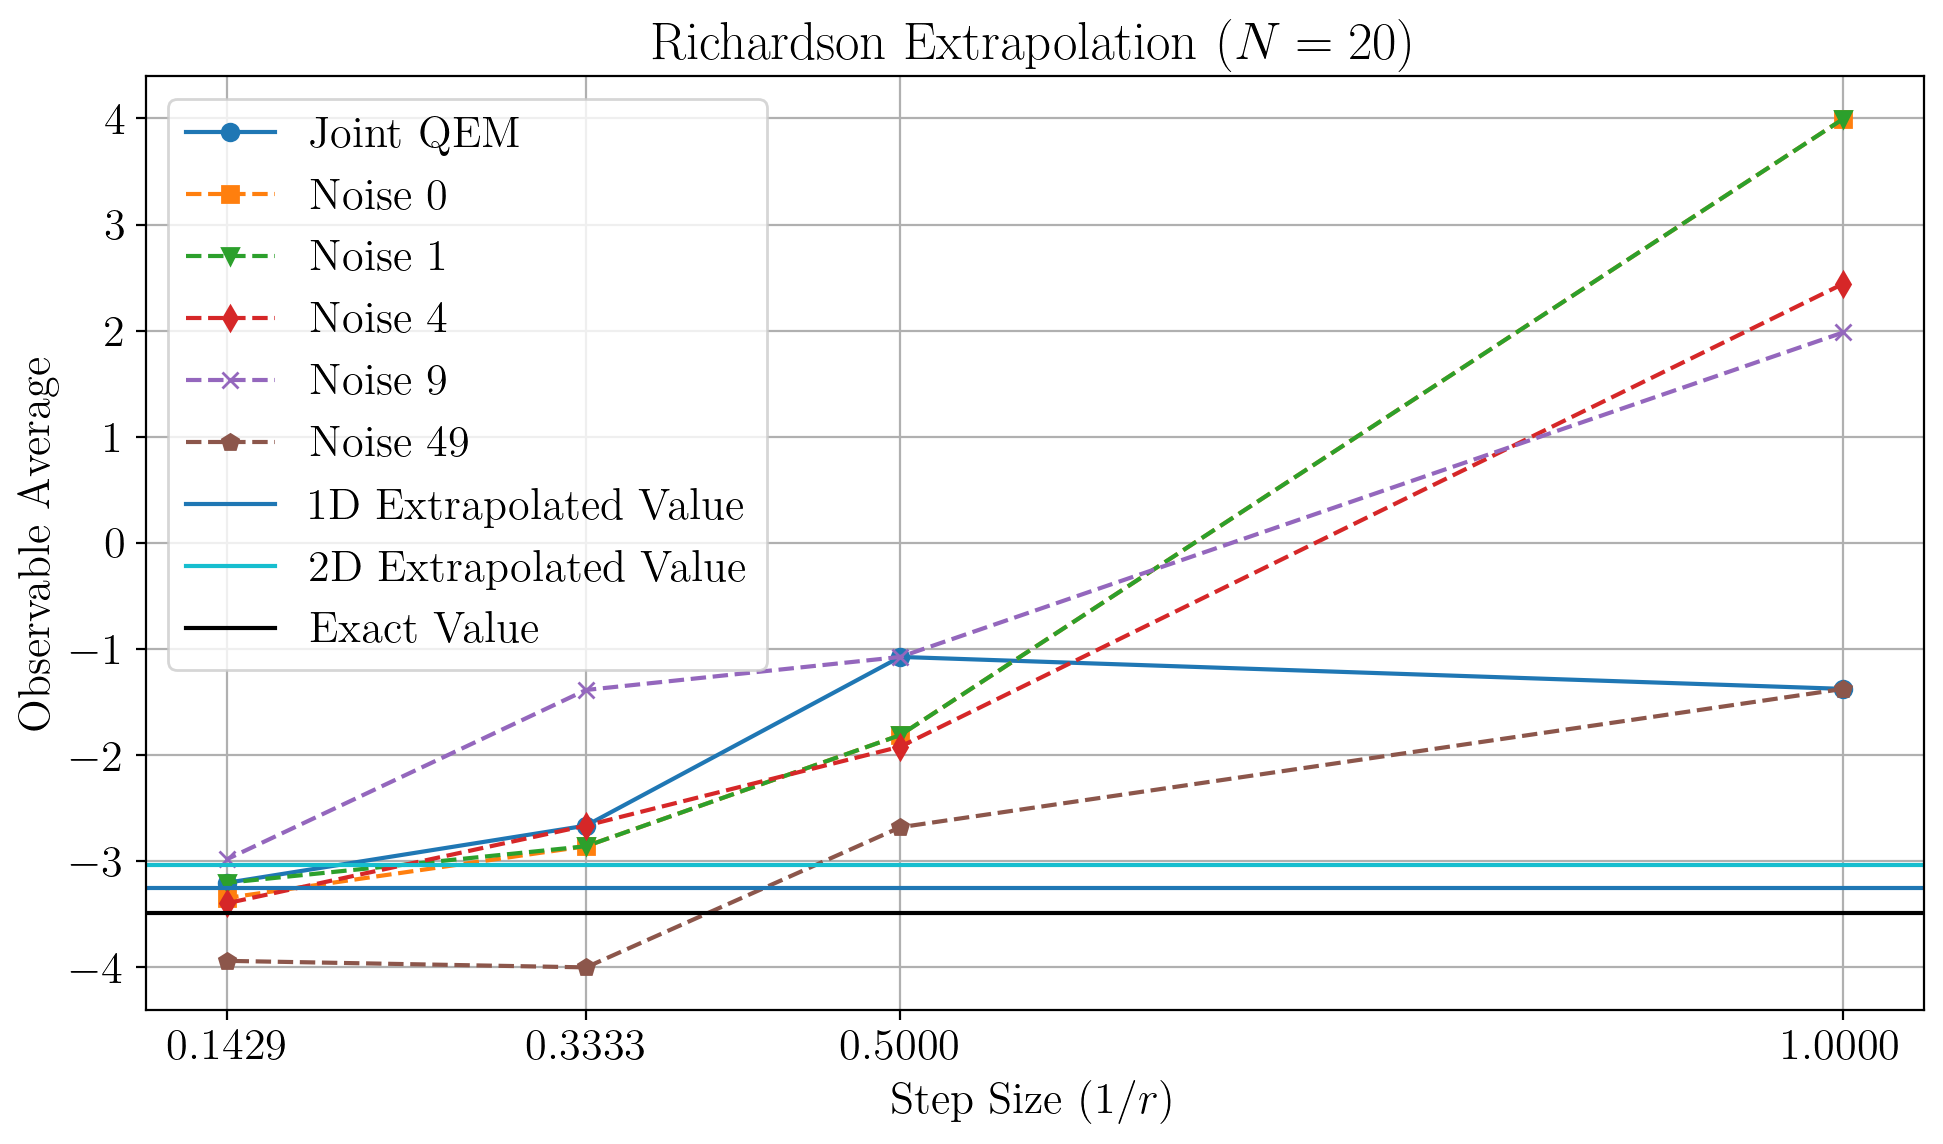

In [30]:
fig, ax = plt.subplots(figsize=(10, 6))

s_list = 1 / np.array(r_list)
ax.plot(s_list, y, 'o-', label='Joint QEM')
ax.plot(s_list, y0, 's--', label='Noise 0')
ax.plot(s_list, y1, 'v--', label=f'Noise {x[-1]}')
ax.plot(s_list, y2, 'd--', label=f'Noise {x[-2]}')
ax.plot(s_list, y3, 'x--', label=f'Noise {x[-3]}')
if len(r_list) > 3:
    ax.plot(s_list, y4, 'p--', label=f'Noise {x[-4]}')

ax.axhline(extraplated_1D, color='C0', linestyle='-', label='1D Extrapolated Value')
if 0:
    ax.axhline(extraplated_y0, color='C1', linestyle='--')
    ax.axhline(extraplated_y1, color='C2', linestyle='--')
    ax.axhline(extraplated_y2, color='C3', linestyle='--')
    ax.axhline(extraplated_y3, color='C4', linestyle='--')

ax.axhline(y=extrapolated_2D, color='C9', linestyle='-', label='2D Extrapolated Value')
ax.axhline(y=exact, color='k', linestyle='-', label='Exact Value')

ax.set(xlabel='Step Size $(1/r)$', 
       ylabel='Observable Average', 
       title=f'Richardson Extrapolation ($N={N}$)',
       xticks=s_list)

ax.legend()
ax.grid()
fig.tight_layout()
plt.show()

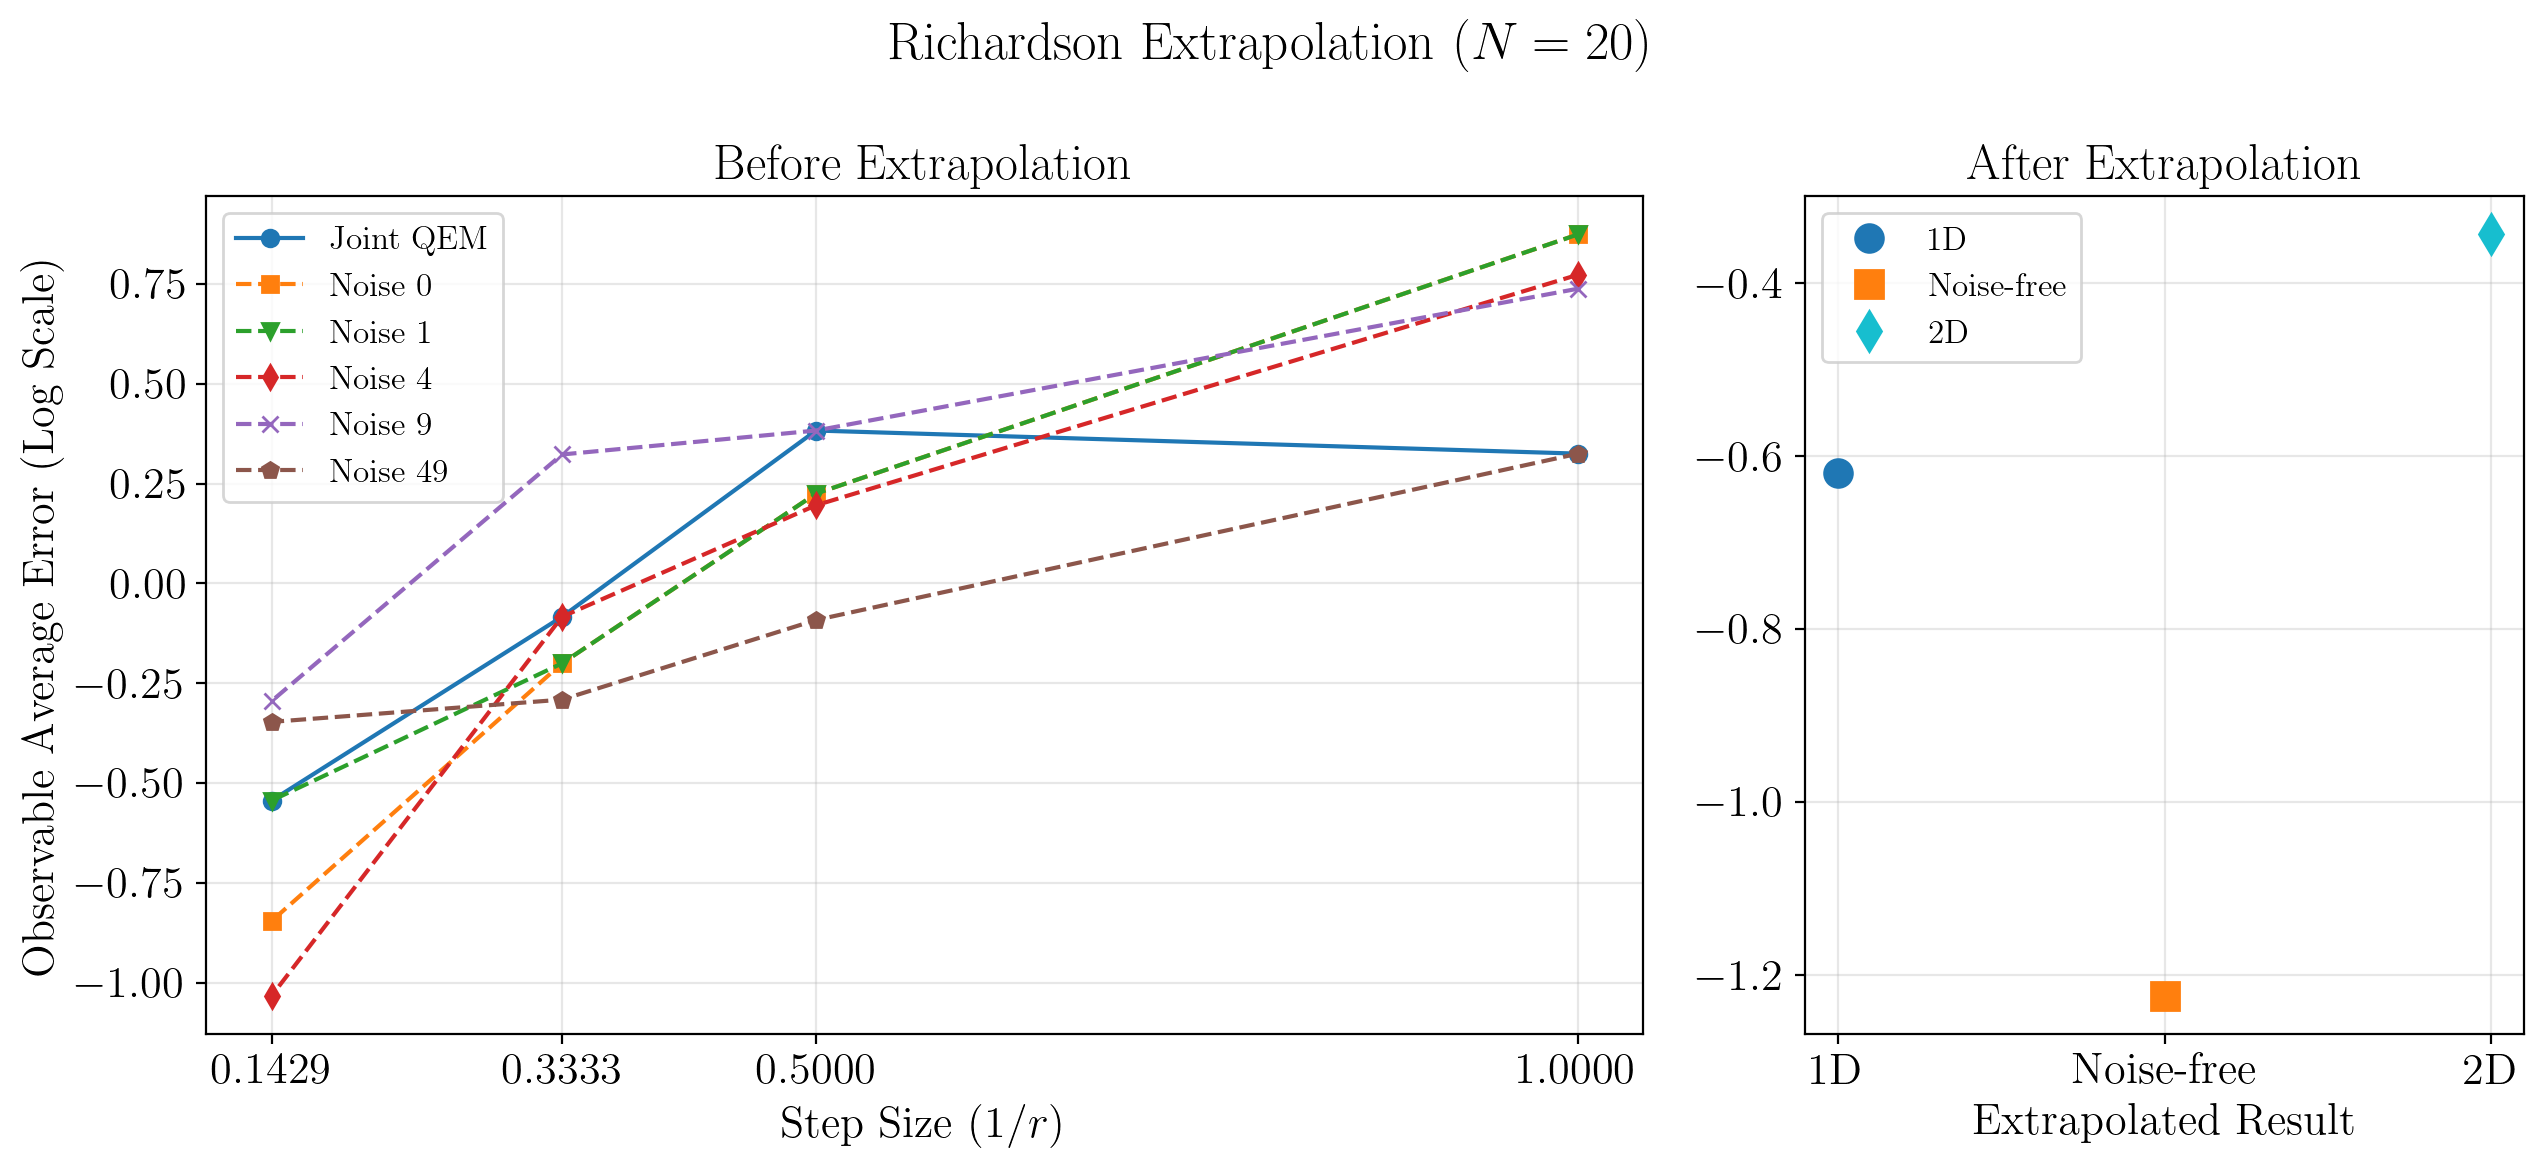

In [31]:
s_list = 1 / np.array(r_list)

raw_error_series = [
    ("Joint QEM", s_list, np.log10(np.abs(np.array(y) - exact)), "o-", "C0"),
    ("Noise 0", s_list, np.log10(np.abs(np.array(y0) - exact)), "s--", "C1"),
    (f"Noise {x[-1]}", s_list, np.log10(np.abs(np.array(y1) - exact)), "v--", "C2"),
    (f"Noise {x[-2]}", s_list, np.log10(np.abs(np.array(y2) - exact)), "d--", "C3"),
    (f"Noise {x[-3]}", s_list, np.log10(np.abs(np.array(y3) - exact)), "x--", "C4"),
]
if len(r_list) > 3:
    raw_error_series.append((f"Noise {x[-4]}", s_list, np.log10(np.abs(np.array(y4) - exact)), "p--", "C5"))

after_error_labels = ["1D", "Noise-free", "2D"]
after_error_values = np.array([
    np.log10(abs(extraplated_1D - exact)),
    np.log10(abs(extraplated_y0 - exact)),
    np.log10(abs(extrapolated_2D - exact)),
])
after_error_markers = ["o", "s", "d"]
after_error_colors = ["C0", "C1", "C9"]

fig, axs = plt.subplots(
    1,
    2,
    figsize=(13, 6),
    # sharey=True,
    gridspec_kw={"width_ratios": [2, 1]},
)

for label, x_values, y_values, style, color in raw_error_series:
    axs[0].plot(x_values, y_values, style, color=color, label=label)
axs[0].set_title("Before Extrapolation", fontsize=18)
axs[0].set_xlabel("Step Size $(1/r)$")
axs[0].set_ylabel("Observable Average Error (Log Scale)")
axs[0].set_xticks(s_list)
axs[0].legend(loc="best", fontsize=12)
axs[0].grid(alpha=0.3)

x_after = np.arange(1, len(after_error_labels) + 1)
for xpos, ypos, label, marker, color in zip(x_after, after_error_values, after_error_labels, after_error_markers, after_error_colors):
    axs[1].plot(xpos, ypos, marker=marker, color=color, markersize=10, linestyle="None", label=label)
axs[1].set_title("After Extrapolation", fontsize=18)
axs[1].set_xlabel("Extrapolated Result")
axs[1].set_xticks(x_after)
axs[1].set_xticklabels(after_error_labels)
axs[1].grid(alpha=0.3)
axs[1].legend(loc="best", fontsize=12)

fig.suptitle(f"Richardson Extrapolation ($N={N}$)", y=0.98)
fig.tight_layout()
plt.show()